# TP2 — <!-- BEGIN SOLUTION -->SOLUTION (instructors only) — <!-- END SOLUTION -->Getting the data yourself: Copernicus Marine

**Suggested duration: ~3h**

In TP1 the data were already on Kabre. Today **you download them yourself** from the [Copernicus Marine Service](https://marine.copernicus.eu), then plot them.

## How to work through this notebook
- Cells marked `# TODO` contain code **you need to complete**. Everything else (imports, helper functions, plot formatting) is already written.
- After each exercise, a **✅ Check** box tells you what a correct result should look like — use it to self-correct before moving on.
- Stuck on a `# TODO`? Below each exercise, a **💡 Hint** box (and, as a last resort, a **🔑 Solution** box) can be opened with a click. Try for a few minutes before opening them!
- **🚀 Advanced track** blocks are optional: if you finish an exercise before the others, try them while the instructor helps the rest of the group.

> ⚠️ **Download etiquette**: ~20 people will run the same requests at the same time. Keep the time windows and boxes **as given** (a few months, a ~12°×10° box). Every file here is < 25 MB.

## Reminder from Course 1
| Term | Meaning |
|---|---|
| **L4** | gridded, gap-filled product: satellite/in situ data **interpolated** onto a regular grid, no holes |
| **Observation product** | built only from measurements (satellite, Argo, CTD…) |
| **Reanalysis** | a numerical model continuously corrected by observations (data assimilation) |

## Today's study area: the Pacific coast of Costa Rica in winter
Box: **lon −92 → −80, lat 4 → 14**. From January to March, strong trade-wind bursts cross the mountain gap of Central America and blow over the **Gulf of Papagayo** (the *Papagayo jet*). They mix and upwell cold water, and offshore sits the **Costa Rica Dome**, where the thermocline comes very close to the surface.
- Exercise 1a: surface temperature seen by satellites (OSTIA SST L4)
- Exercise 1b: temperature in 3D (ARMOR3D, satellite + in situ)
- Exercise 2a: temperature, salinity and currents from an ocean reanalysis (GLORYS12)
- Exercise 2b: the wind that drives it all (scatterometer-corrected ERA5 winds)

---
## Exercise 0 — Copernicus Marine account and login

1. Create a free account at <https://data.marine.copernicus.eu/register>.
2. Open a **terminal** in JupyterHub (*File → New → Terminal*) and type:
   ```bash
   copernicusmarine login
   ```
   Enter your username and password when asked. Your credentials are saved once and for all in `~/.copernicusmarine/`.

> 🔒 **Never write your password in a notebook**: notebooks get shared, emailed, pushed to GitHub…

Then check from the notebook that the login worked:

In [62]:
import copernicusmarine

copernicusmarine.login(check_credentials_valid=True)

INFO - 2026-09-30T22:32:09Z - Checking if credentials are valid.
INFO - 2026-09-30T22:32:09Z - Valid credentials from configuration file.


True

**✅ Check**: the cell prints `Valid credentials from configuration file.` and returns `True`. If it returns `False`, redo step 2 in the terminal.

---
## Setup — imports, study area and helper functions

Run this cell as is. It defines:
- `download(fname, **kwargs)`: calls `copernicusmarine.subset(**kwargs)` and saves the result in `data_tp2/fname`. **If the file already exists, the download is skipped** (so you can re-run cells safely). If the download fails, it falls back to the instructor's backup copy on Kabre, if there is one.
- `show_dataset(dataset_id)`: prints the variables, units and coverage of a dataset.
- `base_map(ax, title, extent=None)`: adds land, coastlines and grid to a map (Costa Rica box by default).

In [63]:
import shutil
from datetime import datetime, timezone
from pathlib import Path

import copernicusmarine
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

# Study area: Pacific coast of Costa Rica (Gulf of Papagayo + Costa Rica Dome)
LON_MIN, LON_MAX = -92, -80
LAT_MIN, LAT_MAX = 4, 14

# Where your downloads go (created next to this notebook)
DATA_DIR = Path("data_tp2")
DATA_DIR.mkdir(exist_ok=True)

# Instructor's backup copy on Kabre, used only if a download fails
OBS_DIR = "/data0/user/gcambon/DATA/DATASETS_PSF/"
BACKUP_DIR = Path(OBS_DIR) / "TP3_BACKUP"


def download(fname, **kwargs):
    # Download a Copernicus Marine subset to DATA_DIR/fname, skip if it already exists
    todo = [k for k, v in kwargs.items() if v is ...]
    if todo:
        raise ValueError(f"Complete the TODOs first: {todo}")
    out = DATA_DIR / fname
    if out.exists():
        print(f"✓ {out} already there, download skipped ({out.stat().st_size / 1e6:.1f} MB)")
        return out
    try:
        copernicusmarine.subset(output_directory=str(DATA_DIR), output_filename=fname, **kwargs)
    except Exception as err:
        backup = BACKUP_DIR / fname
        if not backup.exists():
            raise
        print(f"⚠ Download failed ({err}).\n  Using the instructor's backup copy: {backup}")
        shutil.copy(backup, out)
    print(f"✓ {out} ({out.stat().st_size / 1e6:.1f} MB)")
    return out


def show_dataset(dataset_id):
    # Print variables, units and coordinate ranges of a Copernicus Marine dataset
    cat = copernicusmarine.describe(dataset_id=dataset_id, disable_progress_bar=True)
    product = cat.products[0]
    part = product.datasets[0].versions[0].parts[0]
    service = next(s for s in part.services if s.service_name == "arco-geo-series")
    print(f"{product.title}\n  product : {product.product_id}\n  dataset : {dataset_id}\n")
    for var in service.variables:
        print(f"  variable {var.short_name!r:20} units: {var.units:10} ({var.standard_name})")
    print()
    for coord in service.variables[0].coordinates:
        if coord.coordinate_id == "time":
            t0, t1 = (datetime.fromtimestamp(v / 1000, tz=timezone.utc).date()
                      for v in (coord.minimum_value, coord.maximum_value))
            print(f"  time      : {t0} → {t1}")
        elif coord.values:
            print(f"  {coord.coordinate_id:9} : {len(coord.values)} levels, {coord.values[0]} → {coord.values[-1]}")
        else:
            print(f"  {coord.coordinate_id:9} : {coord.minimum_value:.3f} → {coord.maximum_value:.3f}, step {coord.step:.3f}")


def base_map(ax, title="", extent=None):
    # extent = [lon_min, lon_max, lat_min, lat_max], the Costa Rica box by default
    ax.set_extent(extent or [LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="#d4c9a8", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle="--", zorder=3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    if title:
        ax.set_title(title, fontsize=11)
    return ax


print(f"Study area: lon [{LON_MIN}, {LON_MAX}]  lat [{LAT_MIN}, {LAT_MAX}]")
print(f"Downloads go to: {DATA_DIR.resolve()}")

Study area: lon [-92, -80]  lat [4, 14]
Downloads go to: /Users/gcambon/DATA/WORK/DEV-locmarca/script-locmarca/Session02/data_tp2


---
## How to find a dataset

1. Browse the catalogue: <https://data.marine.copernicus.eu/products>. Filter by variable (e.g. *Temperature*), area, and *Observations* vs *Models*.
2. On a product page, open **Data access**: each product contains one or more **datasets**, each with its own `dataset_id` (e.g. daily vs monthly).
3. From Python, `copernicusmarine.describe(dataset_id=...)` gives the exact variable names, units and coverage. Our helper `show_dataset()` prints the useful part:

In [64]:
show_dataset("METOFFICE-GLO-SST-L4-REP-OBS-SST")

Global Ocean OSTIA Sea Surface Temperature and Sea Ice Reprocessed
  product : SST_GLO_SST_L4_REP_OBSERVATIONS_010_011
  dataset : METOFFICE-GLO-SST-L4-REP-OBS-SST

  variable 'analysed_sst'       units: kelvin     (sea_surface_foundation_temperature)
  variable 'analysis_error'     units: kelvin     (sea_surface_foundation_temperature standard_error)
  variable 'mask'               units:            (None)
  variable 'sea_ice_fraction'   units: 1          (sea_ice_area_fraction)

  time      : 1981-10-01 → 2026-03-31
  latitude  : -89.975 → 89.975, step 0.050
  longitude : -179.975 → 179.975, step 0.050


The four datasets of this notebook:

| Exercise | What | `dataset_id` | Variables | Resolution |
|---|---|---|---|---|
| 1a | Satellite SST, L4 (OSTIA) | `METOFFICE-GLO-SST-L4-REP-OBS-SST` | `analysed_sst` (K) | 0.05°, daily |
| 1b | 3D temperature & salinity, observations (ARMOR3D) | `cmems_obs-mob_glo_phy_my_0.125deg_P1M-m` | `to` (°C), `so` | 0.125°, monthly |
| 2a | Temperature, salinity, currents, ocean reanalysis (GLORYS12) | `cmems_mod_glo_phy_my_0.083deg_P1M-m` | `thetao` (°C), `so`, `uo`, `vo` (m/s) | 1/12° (0.083°), monthly |
| 2b | 10 m wind, ERA5 corrected by scatterometers | `cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H` | `eastward_wind`, `northward_wind` (m/s) | 0.125°, hourly |

### Cheat-sheet: `copernicusmarine.subset()`
```python
copernicusmarine.subset(
    dataset_id        = "…",                   # which dataset
    variables         = ["var1", "var2"],      # list, exact names from describe
    minimum_longitude = -92, maximum_longitude = -80,   # box (degrees East, negative = West)
    minimum_latitude  =   4, maximum_latitude  =  14,
    start_datetime    = "2023-01-01",          # time window (inclusive)
    end_datetime      = "2023-03-31",
    minimum_depth     = 0, maximum_depth = 500,  # only for 3D datasets (metres, positive down)
    output_directory  = "…", output_filename = "…",  # our download() fills these two for you
)
```
With our helper, you write `download("my_file.nc", dataset_id=..., variables=..., ...)` with the same arguments except the last line.

---
## Exercise 1a — Satellite SST L4 (OSTIA)

**🎯 Your turn**: download the OSTIA SST (`analysed_sst`) over the study area, from **1 January to 31 March 2023**.

In [65]:
### STUDENT: # TODO: complete the arguments (see the table and the cheat-sheet above)
SST_FILE = download(
    "sst_ostia_costarica_2023JFM.nc",
### STUDENT:     dataset_id=...,         # TODO
### STUDENT:     variables=...,          # TODO (a list!)
### BEGIN SOLUTION
    dataset_id="METOFFICE-GLO-SST-L4-REP-OBS-SST",
    variables=["analysed_sst"],
### END SOLUTION
    minimum_longitude=LON_MIN, maximum_longitude=LON_MAX,
### STUDENT:     minimum_latitude=...,   # TODO
### STUDENT:     maximum_latitude=...,   # TODO
### STUDENT:     start_datetime=...,     # TODO
### STUDENT:     end_datetime=...,       # TODO
### BEGIN SOLUTION
    minimum_latitude=LAT_MIN, maximum_latitude=LAT_MAX,
    start_datetime="2023-01-01",
    end_datetime="2023-03-31",
### END SOLUTION
)
### HINT: `dataset_id` and variable name: see the table of the four datasets above.
### HINT: `variables` must be a **list**, even with one variable: `["..."]`. Dates as `"YYYY-MM-DD"`.

INFO - 2026-09-30T22:32:11Z - Selected dataset version: "202003"
INFO - 2026-09-30T22:32:11Z - Selected dataset part: "default"


  0%|          | [00:00<?]

INFO - 2026-09-30T22:32:15Z - Total size of the download: 8.26 MB.


✓ data_tp2/sst_ostia_costarica_2023JFM.nc (8.7 MB)


Open the file and look at it, as in Course 2. Before any `.sel(latitude=slice(a, b))` later on, check the **order of the latitudes**: if they are stored north → south, `slice(4, 14)` silently returns an empty selection.

In [66]:
ds_sst = xr.open_dataset(SST_FILE)
print(ds_sst)
print("\nLatitudes increasing (south → north)?", bool(ds_sst.latitude[0] < ds_sst.latitude[-1]))

<xarray.Dataset> Size: 35MB
Dimensions:       (time: 90, latitude: 200, longitude: 240)
Coordinates:
  * time          (time) datetime64[ns] 720B 2023-01-01 ... 2023-03-31
  * latitude      (latitude) float32 800B 4.025 4.075 4.125 ... 13.93 13.98
  * longitude     (longitude) float32 960B -91.97 -91.93 ... -80.07 -80.03
Data variables:
    analysed_sst  (time, latitude, longitude) float64 35MB ...
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              servicedesk.cmems@mercator-ocean.eu
    ...                         ...
    time_coverage_end:          19811002T000000Z
    time_coverage_start:        19811001T000000Z
    title:                      Global SST & Sea Ice Analysis, 

**🎯 Your turn**: map the **mean SST over the three months**, in °C.

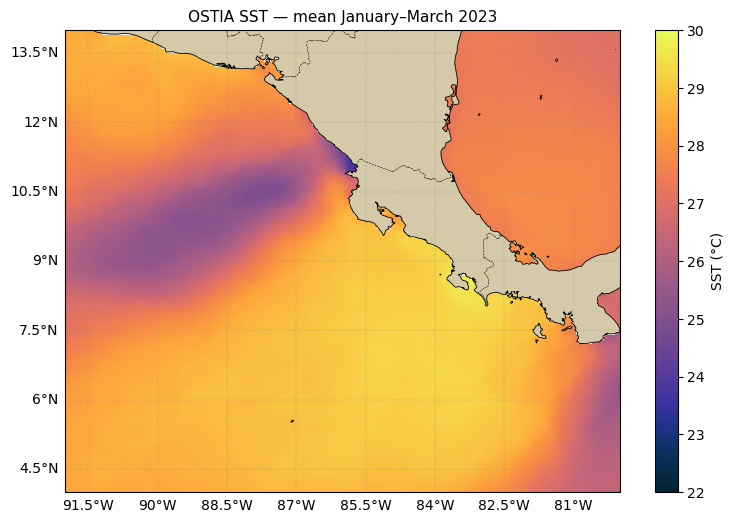

In [67]:
### STUDENT: # TODO: convert Kelvin -> Celsius
### STUDENT: sst = ds_sst["analysed_sst"]  # <-- to complete
### STUDENT:
### STUDENT: # TODO: time mean
### STUDENT: sst_mean = sst  # <-- to complete
### BEGIN SOLUTION
sst = ds_sst["analysed_sst"] - 273.15      # Kelvin -> Celsius
sst_mean = sst.mean(dim="time")
### END SOLUTION

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
sst_mean.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal,
              vmin=22, vmax=30, cbar_kwargs={"label": "SST (°C)"})
base_map(ax, "OSTIA SST — mean January–March 2023")
plt.show()
### HINT: Kelvin → Celsius: subtract 273.15.
### HINT: Time mean: `.mean(dim="time")`.

A 3-month mean smooths out short events. Now look at **a single day**: 16 January 2023, right after a Papagayo wind burst.

**🎯 Your turn**: select that day.

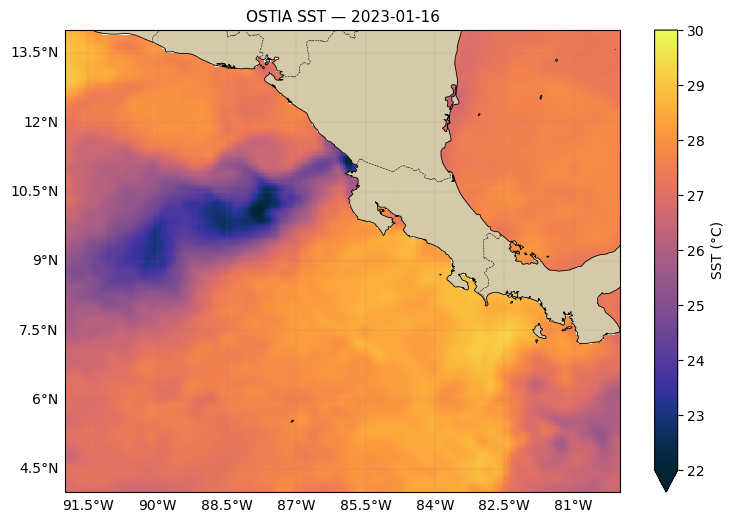

In [68]:
DAY = "2023-01-16"
### STUDENT: # TODO: select this day (hint: .sel(time=...))
### STUDENT: sst_day = sst  # <-- to complete
### BEGIN SOLUTION
sst_day = sst.sel(time=DAY)
### END SOLUTION

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
sst_day.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal,
             vmin=22, vmax=30, cbar_kwargs={"label": "SST (°C)"})
base_map(ax, f"OSTIA SST — {DAY}")
plt.show()
### HINT: `.sel(time=DAY)` selects one date.

**✅ Check**
- The file is ~8–9 MB, with dimensions `time: 90, latitude: 200, longitude: 240` (0.05° grid), latitudes increasing.
- Mean SST between ~23.5 °C and ~30 °C: warm (28–30 °C) in the south of the box and along the Pacific coast of Costa Rica and Panama, ~27 °C on the Caribbean side.
- A **cold tongue** (24–25 °C) extends west-south-west from the Gulf of Papagayo (~11°N, 86°W) towards 9°N, 91°W. It is much sharper on 16 January: below 22 °C near the coast, while the water around it is at 27–28 °C.
- If your values are around 300, you forgot the Kelvin → Celsius conversion. If your day map is empty, check the date format (`"YYYY-MM-DD"`).

---
## Exercise 1b — Temperature in 3D (ARMOR3D)

The satellite only sees the surface. **ARMOR3D** combines satellite data (SST, sea level) with in situ profiles (Argo, CTD…) to reconstruct temperature and salinity **at depth**, as monthly maps.

**🎯 Your turn**: download `to` and `so` over the study area, **for all of 2023**, **between 0 and 500 m**. Look at the table above for the `dataset_id`, and at the cheat-sheet for the depth arguments.

In [69]:
### STUDENT: # TODO: complete the arguments
T3D_FILE = download(
    "armor3d_costarica_2023.nc",
### STUDENT:     dataset_id=...,        # TODO
### STUDENT:     variables=...,         # TODO
### BEGIN SOLUTION
    dataset_id="cmems_obs-mob_glo_phy_my_0.125deg_P1M-m",
    variables=["to", "so"],
### END SOLUTION
    minimum_longitude=LON_MIN, maximum_longitude=LON_MAX,
    minimum_latitude=LAT_MIN, maximum_latitude=LAT_MAX,
### STUDENT:     minimum_depth=...,     # TODO
### STUDENT:     maximum_depth=...,     # TODO
### STUDENT:     start_datetime=...,    # TODO
### STUDENT:     end_datetime=...,      # TODO
### BEGIN SOLUTION
    minimum_depth=0, maximum_depth=500,
    start_datetime="2023-01-01",
    end_datetime="2023-12-31",
### END SOLUTION
)

ds_3d = xr.open_dataset(T3D_FILE)
print(ds_3d)
print("\nLatitudes increasing?", bool(ds_3d.latitude[0] < ds_3d.latitude[-1]))
print("Depth levels (m):", ds_3d.depth.values)
### HINT: ARMOR3D line of the table: `dataset_id`, and the variables `to` (temperature) and `so` (salinity).
### HINT: Depth: 0 to 500 m; dates: the whole year 2023.

INFO - 2026-09-30T22:32:16Z - Selected dataset version: "202511"
INFO - 2026-09-30T22:32:16Z - Selected dataset part: "default"


  0%|          | [00:00<?]

INFO - 2026-09-30T22:32:20Z - Total size of the download: 10.57 MB.


✓ data_tp2/armor3d_costarica_2023.nc (11.1 MB)
<xarray.Dataset> Size: 44MB
Dimensions:    (time: 12, depth: 30, latitude: 80, longitude: 96)
Coordinates:
  * time       (time) datetime64[ns] 96B 2023-01-01 2023-02-01 ... 2023-12-01
  * depth      (depth) int16 60B 0 5 10 15 20 25 30 ... 275 300 350 400 450 500
  * latitude   (latitude) float32 320B 4.062 4.188 4.312 ... 13.69 13.81 13.94
  * longitude  (longitude) float32 384B -91.94 -91.81 -91.69 ... -80.19 -80.06
Data variables:
    to         (time, depth, latitude, longitude) float64 22MB ...
    so         (time, depth, latitude, longitude) float64 22MB ...
Attributes:
    Conventions:               CF-1.0
    description:               ARMOR3D REP Copernicus Marine Service November...
    domain_name:               GLO
    history:                   2025-10-13 20:10:31 ARMOR3D REP - TSHUV Global...
    institution:               CLS
    lat_max:                   89.9375
    lat_min:                   -82.1875
    lon_max:       

**🎯 Your turn**: map the **annual mean temperature at 100 m**. The depth levels are not regular: use `method="nearest"` to pick the closest level.

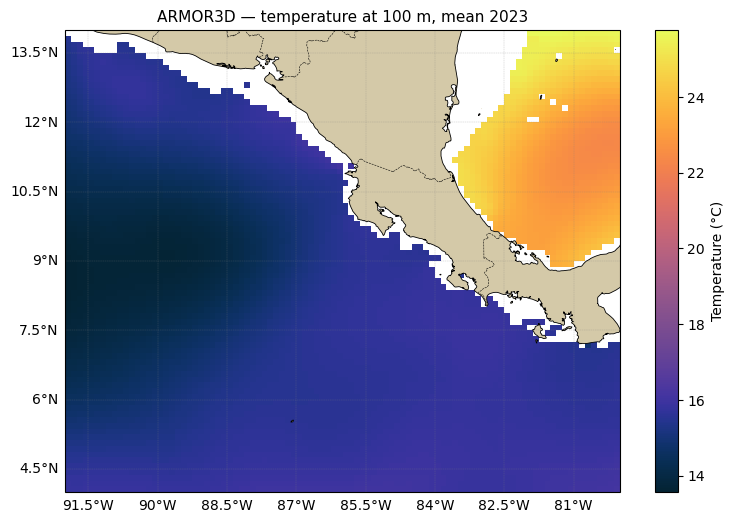

In [70]:
### STUDENT: # TODO: annual mean (over time)
### STUDENT: temp = ds_3d["to"]  # <-- to complete
### STUDENT:
### STUDENT: # TODO: select the level closest to 100 m (hint: .sel(depth=..., method=...))
### STUDENT: temp_100 = temp  # <-- to complete
### BEGIN SOLUTION
temp = ds_3d["to"].mean(dim="time")          # annual mean, still 3D (depth, lat, lon)
temp_100 = temp.sel(depth=100, method="nearest")
### END SOLUTION

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
temp_100.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal,
              cbar_kwargs={"label": "Temperature (°C)"})
base_map(ax, "ARMOR3D — temperature at 100 m, mean 2023")
plt.show()
### HINT: Annual mean: `.mean(dim="time")`.
### HINT: Nearest level: `.sel(depth=100, method="nearest")`.

**🎯 Your turn**: draw a **vertical section** (longitude × depth) along **9°N**, which crosses the Costa Rica Dome. The black line is the **20 °C isotherm**, a common marker of the thermocline.

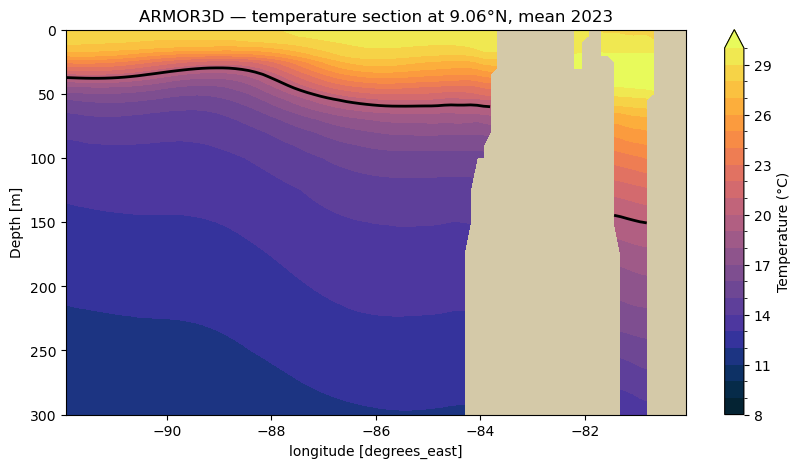

In [71]:
LAT_SECTION = 9
### STUDENT: # TODO: select the latitude closest to LAT_SECTION
### STUDENT: section = temp  # <-- to complete
### BEGIN SOLUTION
section = temp.sel(latitude=LAT_SECTION, method="nearest")
### END SOLUTION

fig, ax = plt.subplots(figsize=(10, 5))
section.plot.contourf(ax=ax, x="longitude", y="depth", levels=np.arange(8, 31, 1),
                      cmap=cmocean.cm.thermal, yincrease=False,
                      cbar_kwargs={"label": "Temperature (°C)"})
section.plot.contour(ax=ax, x="longitude", y="depth", levels=[20],
                     colors="k", linewidths=2, yincrease=False)
ax.set_ylim(300, 0)
ax.set_facecolor("#d4c9a8")                 # land (NaN) in beige
ax.set_title(f"ARMOR3D — temperature section at {float(section.latitude):.2f}°N, mean 2023")
plt.show()
### HINT: `.sel(latitude=LAT_SECTION, method="nearest")` on `temp`.

**✅ Check**
- The file is ~11 MB: `time: 12` (one map per month, dated on the 1st), `depth: 30` levels from 0 to 500 m, `latitude: 80, longitude: 96` (0.125° grid).
- At 100 m, the whole Pacific side is cold (~14–16 °C), coldest (< 14 °C) around 9°N, 90–92°W: that is the **Costa Rica Dome**. At the same depth, the Caribbean is much warmer (~22–25 °C). The white band along the coasts is where the sea floor is shallower than 100 m.
- On the section, the thermocline is **very shallow**: the 20 °C isotherm lies at ~30 m around 89°W (the Dome) and deepens to ~60 m near the Pacific coast (85–86°W). In the Caribbean, east of Costa Rica, it is much deeper (~150 m).
- The depth axis must point **downwards** (surface at the top). If it doesn't, check `yincrease=False`.

---
## Cross-check — OSTIA vs ARMOR3D at the surface

A good habit in science: **get the same number with two independent methods**. Both OSTIA (Exercise 1a) and ARMOR3D (Exercise 1b, top level at 0 m) give a surface temperature. Over the **same box** and the **same period** (January–March 2023), do they agree?

**🎯 Your turn**:
1. OSTIA: the mean of `sst` over time, latitude and longitude, i.e. **everything** (`.mean()` with no argument).
2. ARMOR3D: select the **surface** level (`depth=0`) and the months **January to March** (`.sel(time=slice("2023-01", "2023-03"))`), then average everything.
3. Month by month: OSTIA is daily, ARMOR3D is monthly. To compare them, turn OSTIA into monthly means with `.resample(time="MS").mean()` (`MS` = *month start*, the same dates as ARMOR3D).

In [72]:
### STUDENT: # TODO: ARMOR3D surface level, January to March 2023
### STUDENT: sst_armor = ds_3d["to"]  # <-- to complete
### BEGIN SOLUTION
sst_armor = ds_3d["to"].sel(depth=0).sel(time=slice("2023-01", "2023-03"))
### END SOLUTION

### STUDENT: # TODO: the two means over everything (box + period)
### STUDENT: mean_ostia = ...  # <-- to complete
### STUDENT: mean_armor = ...  # <-- to complete
### BEGIN SOLUTION
mean_ostia = float(sst.mean())
mean_armor = float(sst_armor.mean())
### END SOLUTION
print(f"Mean SST, box + Jan–Mar 2023:  OSTIA = {mean_ostia:.2f} °C   ARMOR3D = {mean_armor:.2f} °C   "
      f"difference = {mean_armor - mean_ostia:+.2f} °C")

# Month by month
### STUDENT: # TODO: monthly means of OSTIA (resample), then average over latitude and longitude
### STUDENT: ostia_monthly = sst  # <-- to complete
### BEGIN SOLUTION
ostia_monthly = sst.resample(time="MS").mean().mean(dim=["latitude", "longitude"])
### END SOLUTION
armor_monthly = sst_armor.mean(dim=["latitude", "longitude"])
table = pd.DataFrame({"OSTIA (°C)": ostia_monthly.values,
                      "ARMOR3D (°C)": armor_monthly.values},
                     index=ostia_monthly.time.dt.strftime("%Y-%m").values)
table["difference"] = table["ARMOR3D (°C)"] - table["OSTIA (°C)"]
print()
print(table.round(2))
### HINT: Surface level of ARMOR3D: `.sel(depth=0)`; period: `.sel(time=slice("2023-01", "2023-03"))`.
### HINT: A single number: `float(da.mean())`.
### HINT: Monthly means: `.resample(time="MS").mean()`, then `.mean(dim=["latitude", "longitude"])`.

Mean SST, box + Jan–Mar 2023:  OSTIA = 27.93 °C   ARMOR3D = 27.88 °C   difference = -0.06 °C

         OSTIA (°C)  ARMOR3D (°C)  difference
2023-01       27.56         27.52       -0.04
2023-02       27.72         27.71       -0.01
2023-03       28.50         28.40       -0.10


**✅ Check**
- Box mean: OSTIA ≈ 27.9 °C, ARMOR3D ≈ 27.9 °C, a difference of only a few hundredths of a degree (well under 0.5 °C).
- Month by month, the difference stays below 0.1 °C, and both show the warming from January (~27.5 °C) to March (~28.5 °C).
- If `ostia_monthly` has 90 values instead of 3, the `resample` is missing.

**💬 Discuss with your neighbour**: why is the agreement not perfect? Think about the resolution (0.05° vs 0.125°), about the land masks (the coastal band missing in ARMOR3D), about what "surface" means (OSTIA is a *foundation* SST, just below the layer warmed by the sun during the day). And a trap: ARMOR3D **uses satellite SST as an input**. Are the two methods really independent?

---
## Exercise 1c — Your own area

Now choose **your own area** (for example the one of your Thursday mini-project) and download the OSTIA SST there, for the same period.

Rules:
- keep the box **smaller than 15° × 15°** (a 10° × 10° box is ~7 MB for 3 months);
- give the file a **new name**, otherwise `download()` finds the Costa Rica file and skips the download;
- longitudes are in degrees **East**: west of Greenwich they are **negative** (Costa Rica is at −85°).

We use new variables `MY_...` so that the Costa Rica box (`LON_MIN`…) stays unchanged for the next exercises.

*Example in the solution: the Gulf of Tehuantepec (southern Mexico), another gap in the mountains with a winter wind jet, like Papagayo.*

INFO - 2026-09-30T22:32:21Z - Selected dataset version: "202003"
INFO - 2026-09-30T22:32:21Z - Selected dataset part: "default"


  0%|          | [00:00<?]

INFO - 2026-09-30T22:32:26Z - Total size of the download: 6.88 MB.


✓ data_tp2/sst_ostia_tehuantepec_2023JFM.nc (7.2 MB)


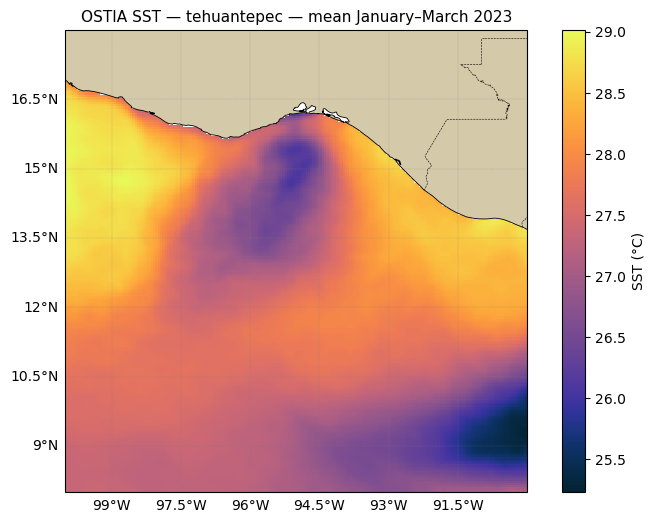

In [73]:
### STUDENT: MY_NAME = "..."                               # TODO: short name, used in the file name
### STUDENT: MY_LON_MIN, MY_LON_MAX = ..., ...             # TODO
### STUDENT: MY_LAT_MIN, MY_LAT_MAX = ..., ...             # TODO
### BEGIN SOLUTION
MY_NAME = "tehuantepec"                       # short name, used in the file name
MY_LON_MIN, MY_LON_MAX = -100, -90
MY_LAT_MIN, MY_LAT_MAX = 8, 18
### END SOLUTION

assert MY_LON_MAX - MY_LON_MIN <= 15 and MY_LAT_MAX - MY_LAT_MIN <= 15, "Box too big: keep it under 15° × 15°"
assert MY_LON_MIN < MY_LON_MAX and MY_LAT_MIN < MY_LAT_MAX, "Check the order: MIN must be smaller than MAX"

### STUDENT: # TODO: same request as Exercise 1a, but with your box (MY_...)
MY_FILE = download(
    f"sst_ostia_{MY_NAME}_2023JFM.nc",
    dataset_id="METOFFICE-GLO-SST-L4-REP-OBS-SST",
    variables=["analysed_sst"],
### STUDENT:     minimum_longitude=..., maximum_longitude=...,   # TODO
### STUDENT:     minimum_latitude=..., maximum_latitude=...,     # TODO
### BEGIN SOLUTION
    minimum_longitude=MY_LON_MIN, maximum_longitude=MY_LON_MAX,
    minimum_latitude=MY_LAT_MIN, maximum_latitude=MY_LAT_MAX,
### END SOLUTION
    start_datetime="2023-01-01",
    end_datetime="2023-03-31",
)

### STUDENT: # TODO: time mean, in °C
### STUDENT: my_sst = xr.open_dataset(MY_FILE)["analysed_sst"]  # <-- to complete
### BEGIN SOLUTION
my_sst = xr.open_dataset(MY_FILE)["analysed_sst"].mean(dim="time") - 273.15
### END SOLUTION

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
my_sst.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal,
            cbar_kwargs={"label": "SST (°C)"})
base_map(ax, f"OSTIA SST — {MY_NAME} — mean January–March 2023",
         extent=[MY_LON_MIN, MY_LON_MAX, MY_LAT_MIN, MY_LAT_MAX])
plt.show()
### HINT: Pick a box of your choice, at most 15° × 15°, with MIN < MAX (e.g. the Gulf of Tehuantepec: 100°W–90°W, 8°N–18°N).
### HINT: In `download()`, use your `MY_LON_MIN`, `MY_LON_MAX`, `MY_LAT_MIN`, `MY_LAT_MAX`.
### HINT: Time mean then Kelvin → Celsius: `.mean(dim="time") - 273.15`.
### NO REVEAL

**✅ Check**
- The download message gives the size: it should be at most ~15 MB (a 15° × 15° box). If the `assert` stops you, your box is too big or MIN/MAX are swapped.
- The map covers **your** box, and the colours make sense for the region and the season (tropics: 24–30 °C; mid-latitudes in winter: much colder in the northern hemisphere).
- For the Tehuantepec example: a cold tongue (~26 °C) spreading south from the Gulf of Tehuantepec (~15°N, 95°W), in 27.5–29 °C water: the same mechanism as Papagayo. In the south-east corner you can even see the tip of the Papagayo cold tongue.

---
## Debugging exercise — read the error message!

A colleague wants to download **the first week of the whole OSTIA record** over our box. They wrote the cell below from memory, calling `copernicusmarine.subset()` directly (without our `download()` helper)… and it fails.

**🎯 Your turn**:
1. Run the cell and **read the last line of the error**: what is it complaining about?
2. Use `show_dataset("METOFFICE-GLO-SST-L4-REP-OBS-SST")` (cell below) to find the right information.
3. Fix the cell and run it again. ⚠️ There are **two** bugs: when you fix the first one, a second error appears.

In [74]:
# ❌ Buggy version (left as is on purpose)
# Here we call copernicusmarine.subset() directly, without our download() helper
copernicusmarine.subset(
    output_directory=str(DATA_DIR), output_filename="sst_ostia_first_week.nc", overwrite=True,
    dataset_id="METOFFICE-GLO-SST-L4-REP-OBS-SST",
    variables=["sst"],
    minimum_longitude=LON_MIN, maximum_longitude=LON_MAX,
    minimum_latitude=LAT_MIN, maximum_latitude=LAT_MAX,
    start_datetime="1980-01-01",
    end_datetime="1980-01-07",
)

INFO - 2026-09-30T22:32:27Z - Selected dataset version: "202003"
INFO - 2026-09-30T22:32:27Z - Selected dataset part: "default"


CoordinatesOutOfDatasetBounds: Some of your subset selection [1980-01-01 00:00:00+00:00, 1980-01-07 00:00:00+00:00] for the time dimension exceed the dataset coordinates [1981-10-01 00:00:00+00:00, 2026-03-31 00:00:00+00:00]

In [75]:
show_dataset("METOFFICE-GLO-SST-L4-REP-OBS-SST")

Global Ocean OSTIA Sea Surface Temperature and Sea Ice Reprocessed
  product : SST_GLO_SST_L4_REP_OBSERVATIONS_010_011
  dataset : METOFFICE-GLO-SST-L4-REP-OBS-SST

  variable 'analysed_sst'       units: kelvin     (sea_surface_foundation_temperature)
  variable 'analysis_error'     units: kelvin     (sea_surface_foundation_temperature standard_error)
  variable 'mask'               units:            (None)
  variable 'sea_ice_fraction'   units: 1          (sea_ice_area_fraction)

  time      : 1981-10-01 → 2026-03-31
  latitude  : -89.975 → 89.975, step 0.050
  longitude : -179.975 → 179.975, step 0.050


In [76]:
### STUDENT: # TODO: copy the buggy cell here and fix it
### BEGIN SOLUTION
# ✅ Fixed version
#  bug 1: the record starts on 1981-10-01, not in 1980      -> CoordinatesOutOfDatasetBounds
#  bug 2: the variable is called "analysed_sst", not "sst"  -> VariableDoesNotExistInTheDataset
copernicusmarine.subset(
    output_directory=str(DATA_DIR), output_filename="sst_ostia_first_week.nc", overwrite=True,
    dataset_id="METOFFICE-GLO-SST-L4-REP-OBS-SST",
    variables=["analysed_sst"],
    minimum_longitude=LON_MIN, maximum_longitude=LON_MAX,
    minimum_latitude=LAT_MIN, maximum_latitude=LAT_MAX,
    start_datetime="1981-10-01",
    end_datetime="1981-10-07",
)
print(xr.open_dataset(DATA_DIR / "sst_ostia_first_week.nc").time.values)
### END SOLUTION
### HINT: Read the **last line** of the error: its name (e.g. `CoordinatesOutOfDatasetBounds`) says what is wrong.
### HINT: `show_dataset("METOFFICE-GLO-SST-L4-REP-OBS-SST")` gives the start date of the record and the variable name.

INFO - 2026-09-30T22:32:28Z - Selected dataset version: "202003"
INFO - 2026-09-30T22:32:28Z - Selected dataset part: "default"
INFO - 2026-09-30T22:32:30Z - Total size of the download: 669.92 KB.


['1981-10-01T00:00:00.000000000' '1981-10-02T00:00:00.000000000'
 '1981-10-03T00:00:00.000000000' '1981-10-04T00:00:00.000000000'
 '1981-10-05T00:00:00.000000000' '1981-10-06T00:00:00.000000000'
 '1981-10-07T00:00:00.000000000']


**✅ Check**
- First error: `CoordinatesOutOfDatasetBounds: Some of your subset selection [1980-01-01 ..., 1980-01-07 ...] for the time dimension exceed the dataset coordinates [1981-10-01 ..., ...]` → the record starts on **1 October 1981**.
- Second error: `VariableDoesNotExistInTheDataset: The variable 'sst' is neither a variable or a standard name in the dataset.` → the exact name, given by `show_dataset`, is `analysed_sst`.
- Once both are fixed, the file (~0.7 MB) contains 7 days, from 1981-10-01 to 1981-10-07.
- Lesson: the **last line** of a Python error is almost always the most useful. And `describe` / `show_dataset` answers most questions about a dataset.

---
## Exercise 2a — Ocean reanalysis (GLORYS12)

So far we have used **observation** products. **GLORYS12** is a **reanalysis**: the NEMO ocean model at 1/12° (~9 km), continuously corrected by observations (satellite SST and sea level, Argo profiles…). Being a model, it gives **all variables everywhere**, including the currents, which are hardly ever observed.

**🎯 Your turn**: download temperature, salinity and the two current components (`thetao`, `so`, `uo`, `vo`) over the study area, **from January to March 2023** (same period as Exercise 1a), **between 0 and 500 m**.

> ℹ️ You will see a `WARNING` saying that your depth range exceeds the dataset coordinates: that's harmless. The first model level is at 0.49 m, not at 0 m.

In [77]:
### STUDENT: # TODO: complete the arguments
GLO_FILE = download(
    "glorys12_costarica_2023JFM.nc",
### STUDENT:     dataset_id=...,        # TODO
### STUDENT:     variables=...,         # TODO (4 variables)
### BEGIN SOLUTION
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1M-m",
    variables=["thetao", "so", "uo", "vo"],
### END SOLUTION
    minimum_longitude=LON_MIN, maximum_longitude=LON_MAX,
    minimum_latitude=LAT_MIN, maximum_latitude=LAT_MAX,
### STUDENT:     minimum_depth=...,     # TODO
### STUDENT:     maximum_depth=...,     # TODO
### STUDENT:     start_datetime=...,    # TODO
### STUDENT:     end_datetime=...,      # TODO
### BEGIN SOLUTION
    minimum_depth=0, maximum_depth=500,
    start_datetime="2023-01-01",
    end_datetime="2023-03-31",
### END SOLUTION
)

ds_glo = xr.open_dataset(GLO_FILE)
print(ds_glo)
print("\nLatitudes increasing?", bool(ds_glo.latitude[0] < ds_glo.latitude[-1]))
print("Depth levels (m):", ds_glo.depth.values.round(1))
### HINT: GLORYS12 line of the table (monthly): `dataset_id`, and the 4 variables `thetao`, `so`, `uo`, `vo`.
### HINT: Depth 0 to 500 m; dates: January to March 2023.

INFO - 2026-09-30T22:32:30Z - Selected dataset version: "202311"
INFO - 2026-09-30T22:32:30Z - Selected dataset part: "default"
WARNING - 2026-09-30T22:32:30Z - Some of your subset selection [0.0, 500.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]


  0%|          | [00:00<?]

INFO - 2026-09-30T22:32:41Z - Total size of the download: 12.47 MB.


✓ data_tp2/glorys12_costarica_2023JFM.nc (13.1 MB)
<xarray.Dataset> Size: 52MB
Dimensions:    (time: 3, depth: 31, latitude: 121, longitude: 145)
Coordinates:
  * time       (time) datetime64[ns] 24B 2023-01-01 2023-02-01 2023-03-01
  * depth      (depth) float32 124B 0.494 1.541 2.646 ... 318.1 380.2 453.9
  * latitude   (latitude) float32 484B 4.0 4.083 4.167 4.25 ... 13.83 13.92 14.0
  * longitude  (longitude) float32 580B -92.0 -91.92 -91.83 ... -80.08 -80.0
Data variables:
    thetao     (time, depth, latitude, longitude) float64 13MB ...
    so         (time, depth, latitude, longitude) float64 13MB ...
    uo         (time, depth, latitude, longitude) float64 13MB ...
    vo         (time, depth, latitude, longitude) float64 13MB ...
Attributes: (12/15)
    Conventions:                   CF-1.6
    area:                          GLOBAL
    contact:                       servicedesk.cmems@mercator-ocean.eu
    credit:                        E.U. Copernicus Marine Service Informat

**🎯 Your turn**: map the **model SST** (first level, `isel(depth=0)`) averaged over the 3 months, with the **surface currents** as arrows (one arrow out of 8, otherwise the map is unreadable).

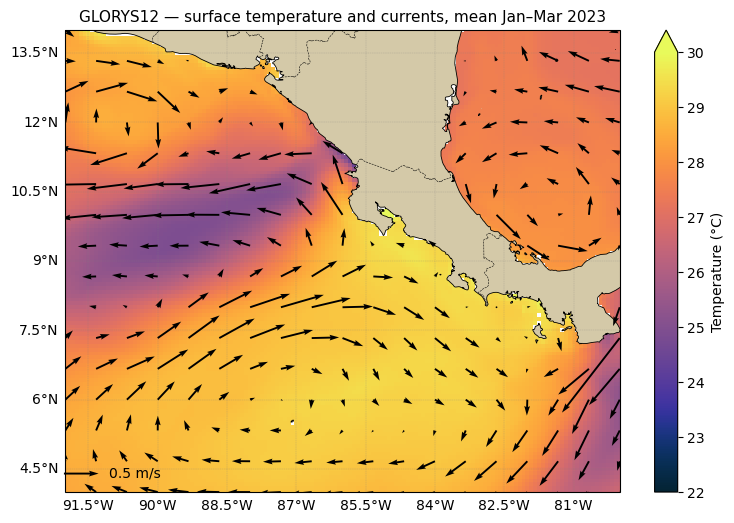

In [78]:
### STUDENT: # TODO: time mean of the whole dataset
### STUDENT: glo_mean = ds_glo  # <-- to complete
### BEGIN SOLUTION
glo_mean = ds_glo.mean(dim="time")           # Jan–Mar mean, all variables
glo_surf = glo_mean.isel(depth=0)            # first model level (0.49 m)
### END SOLUTION

### STUDENT: # TODO: keep only the first model level (hint: .isel(depth=...))
### STUDENT: glo_surf = glo_mean  # <-- to complete
### STUDENT:
### STUDENT: # TODO: pick the three variables
### STUDENT: sst_model = ...  # <-- to complete
### STUDENT: uo = ...         # <-- to complete
### STUDENT: vo = ...         # <-- to complete
### BEGIN SOLUTION
sst_model = glo_surf["thetao"]
uo = glo_surf["uo"]
vo = glo_surf["vo"]
### END SOLUTION

step = 8                                     # one arrow every 8 grid points
fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
sst_model.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal,
               vmin=22, vmax=30, cbar_kwargs={"label": "Temperature (°C)"})
q = ax.quiver(uo.longitude[::step], uo.latitude[::step],
              uo[::step, ::step], vo[::step, ::step],
              transform=ccrs.PlateCarree(), scale=8, zorder=4)
ax.quiverkey(q, 0.06, 0.04, 0.5, "0.5 m/s", labelpos="E", coordinates="axes", zorder=5)
base_map(ax, "GLORYS12 — surface temperature and currents, mean Jan–Mar 2023")
plt.show()
### HINT: `.mean(dim="time")` works on the whole Dataset (all variables at once).
### HINT: First level: `.isel(depth=0)`; then pick variables with `glo_surf["thetao"]`, etc.

**🎯 Your turn**: draw the **temperature and salinity sections** along 9°N (the same latitude as the ARMOR3D section of Exercise 1b).

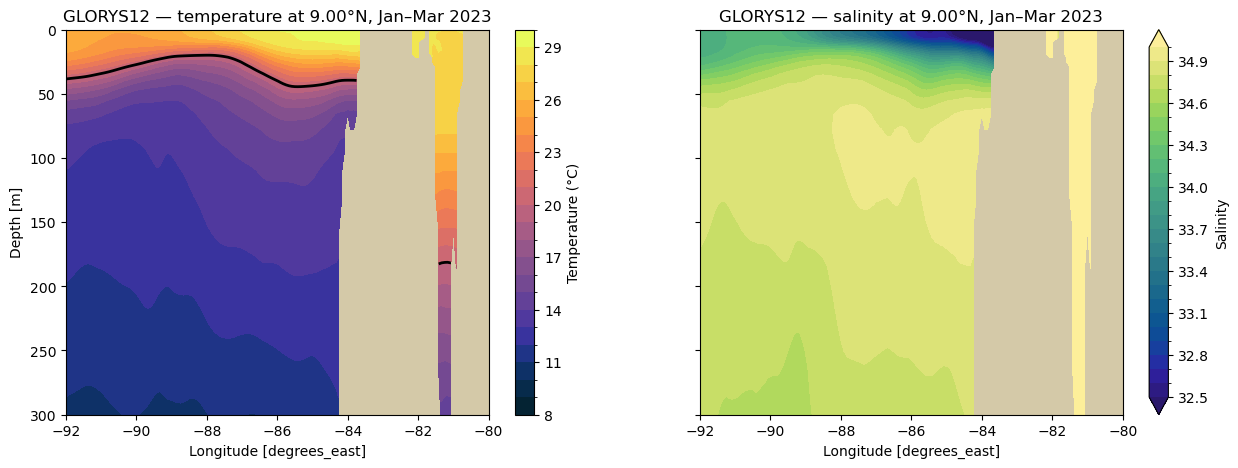

In [79]:
### STUDENT: # TODO: select the latitude closest to LAT_SECTION in glo_mean
### STUDENT: sec_glo = glo_mean  # <-- to complete
### BEGIN SOLUTION
sec_glo = glo_mean.sel(latitude=LAT_SECTION, method="nearest")
### END SOLUTION

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sec_glo["thetao"].plot.contourf(ax=axes[0], x="longitude", y="depth", levels=np.arange(8, 31, 1),
                                cmap=cmocean.cm.thermal, cbar_kwargs={"label": "Temperature (°C)"})
sec_glo["thetao"].plot.contour(ax=axes[0], x="longitude", y="depth", levels=[20],
                               colors="k", linewidths=2)
sec_glo["so"].plot.contourf(ax=axes[1], x="longitude", y="depth", levels=np.arange(32.5, 35.05, 0.1),
                            cmap=cmocean.cm.haline, extend="both", cbar_kwargs={"label": "Salinity"})
for ax in axes:
    ax.set_ylim(300, 0)                      # depth pointing down
    ax.set_facecolor("#d4c9a8")
axes[0].set_title(f"GLORYS12 — temperature at {float(sec_glo.latitude):.2f}°N, Jan–Mar 2023")
axes[1].set_title(f"GLORYS12 — salinity at {float(sec_glo.latitude):.2f}°N, Jan–Mar 2023")
axes[1].set_ylabel("")
plt.show()
### HINT: Same as the ARMOR3D section: `.sel(latitude=LAT_SECTION, method="nearest")`, here on `glo_mean`.

**✅ Check**
- The file is ~13 MB: `time: 3`, `depth: 31` levels from 0.49 m to 454 m (much closer together near the surface), `latitude: 121, longitude: 145` (1/12° grid).
- **SST**: the same cold tongue as in Exercise 1a, from the Gulf of Papagayo towards the west-south-west (minimum ~24.5 °C near the gulf). West of 86°W, the mean model SST and the mean OSTIA SST differ by less than 0.1 °C: GLORYS assimilates satellite SST.
- **Currents**: an **eastward** band at 7–8°N (~0.4–0.5 m/s, the *North Equatorial Countercurrent*) and a **westward** flow at 10–11°N (~0.5 m/s, under the cold tongue). Together they form an anticlockwise loop around the cold water of the **Costa Rica Dome**. The strongest currents (> 1 m/s) are in the south-east corner (Gulf of Panama).
- **Temperature section**: the 20 °C isotherm is at ~20–30 m around 88–90°W (the Dome) and ~45 m near the coast. It is a bit shallower than in ARMOR3D (Exercise 1b). One reason is that you are comparing Jan–Mar with an annual mean; the other is that a model is not an observation. You will compare the two properly on Thursday.
- **Salinity section**: fresher water at the surface near the coast (32–33, rain and rivers) than offshore (~34.1), and a salinity maximum (~34.9) at ~80 m, just below the thermocline. The narrow Caribbean strip east of 82°W is much saltier (> 35).

---
## Exercise 2b — Wind: the Papagayo jet

The wind product is ERA5 (ECMWF atmospheric reanalysis) **corrected with scatterometer observations** (satellites that measure wind from the roughness of the sea surface). It is **hourly**: that's a lot of time steps, so keep the window to **one month**.

**🎯 Your turn**: download `eastward_wind` and `northward_wind` over the study area, **from 1 January 2023 00:00 to 31 January 2023 23:00**.

In [80]:
### STUDENT: # TODO: complete the arguments (dates with hours: "YYYY-MM-DDTHH:MM:SS")
WIND_FILE = download(
    "wind_l4_costarica_2023-01.nc",
### STUDENT:     dataset_id=...,        # TODO
### STUDENT:     variables=...,         # TODO
### BEGIN SOLUTION
    dataset_id="cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H",
    variables=["eastward_wind", "northward_wind"],
### END SOLUTION
    minimum_longitude=LON_MIN, maximum_longitude=LON_MAX,
    minimum_latitude=LAT_MIN, maximum_latitude=LAT_MAX,
### STUDENT:     start_datetime=...,    # TODO
### STUDENT:     end_datetime=...,      # TODO
### BEGIN SOLUTION
    start_datetime="2023-01-01T00:00:00",
    end_datetime="2023-01-31T23:00:00",
### END SOLUTION
)

ds_wind = xr.open_dataset(WIND_FILE)
print(ds_wind)
print("\nLatitudes increasing?", bool(ds_wind.latitude[0] < ds_wind.latitude[-1]))
### HINT: Wind L4 line of the table: `dataset_id`, variables `eastward_wind`, `northward_wind`.
### HINT: Hourly data: `"2023-01-01T00:00:00"` to `"2023-01-31T23:00:00"`.

INFO - 2026-09-30T22:32:42Z - Selected dataset version: "202211"
INFO - 2026-09-30T22:32:42Z - Selected dataset part: "default"


  0%|          | [00:00<?]

INFO - 2026-09-30T22:32:52Z - Total size of the download: 21.82 MB.


✓ data_tp2/wind_l4_costarica_2023-01.nc (22.9 MB)
<xarray.Dataset> Size: 91MB
Dimensions:         (time: 744, latitude: 80, longitude: 96)
Coordinates:
  * time            (time) datetime64[ns] 6kB 2023-01-01 ... 2023-01-31T23:00:00
  * latitude        (latitude) float32 320B 4.062 4.188 4.312 ... 13.81 13.94
  * longitude       (longitude) float32 384B -91.94 -91.81 ... -80.19 -80.06
Data variables:
    eastward_wind   (time, latitude, longitude) float64 46MB ...
    northward_wind  (time, latitude, longitude) float64 46MB ...
Attributes: (12/27)
    Conventions:                CF-1.6, ACDD-1.3
    date_created:               2024-03-25T23:58:22
    date_modified:              2024-03-25T23:58:22
    geospatial_lat_max:         89.9375
    geospatial_lat_min:         -89.9375
    geospatial_lat_resolution:  0.125
    ...                         ...
    references:                 Copernicus Marine Service Product User Manual...
    summary:                    Global ocean 10-m stress-

744 hourly maps is more than we need. **🎯 Your turn**:
1. Compute **daily means** with `.resample(time="1D").mean()`.
2. Compute the **wind speed** $\sqrt{u^2 + v^2}$ of each day (hint: `np.hypot(u, v)` or `np.sqrt(u**2 + v**2)`).

In [81]:
### STUDENT: # TODO: daily means
### STUDENT: wind_daily = ds_wind  # <-- to complete
### BEGIN SOLUTION
wind_daily = ds_wind.resample(time="1D").mean()
### END SOLUTION
u = wind_daily["eastward_wind"]
v = wind_daily["northward_wind"]
### STUDENT:
### STUDENT: # TODO: wind speed
### STUDENT: speed = ...  # <-- to complete
### BEGIN SOLUTION
speed = np.hypot(u, v)
### END SOLUTION

print(dict(wind_daily.sizes))
### HINT: Daily means: `.resample(time="1D").mean()`.
### HINT: Speed = √(u² + v²): `np.hypot(u, v)` (or `np.sqrt(u**2 + v**2)`).

{'time': 31, 'latitude': 80, 'longitude': 96}


Now the map of the **January mean wind speed**, with arrows for the mean wind direction. We draw only **one arrow out of 6** in each direction, otherwise the map is unreadable.

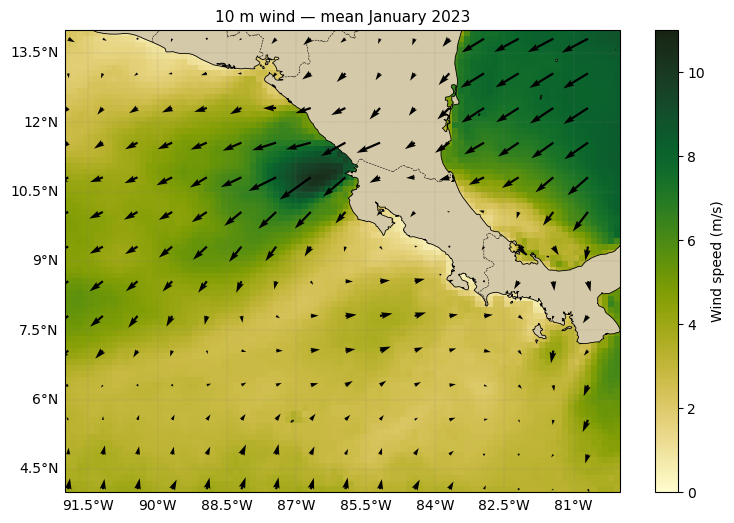

In [82]:
### STUDENT: # TODO: time means of speed, u and v
### STUDENT: speed_mean = ...  # <-- to complete
### STUDENT: u_mean = ...      # <-- to complete
### STUDENT: v_mean = ...      # <-- to complete
### BEGIN SOLUTION
speed_mean = speed.mean(dim="time")
u_mean = u.mean(dim="time")
v_mean = v.mean(dim="time")
### END SOLUTION

step = 6                                     # one arrow every 6 grid points
fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
speed_mean.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.speed,
                vmin=0, vmax=11, cbar_kwargs={"label": "Wind speed (m/s)"})
ax.quiver(u_mean.longitude[::step], u_mean.latitude[::step],
          u_mean[::step, ::step], v_mean[::step, ::step],
          transform=ccrs.PlateCarree(), scale=150, zorder=4)
base_map(ax, "10 m wind — mean January 2023")
plt.show()
### HINT: `.mean(dim="time")` on `speed`, `u` and `v`.

The jet is not steady: it blows in **bursts** of a few days. Plot the daily wind speed at the exit of the Gulf of Papagayo (10.5°N, 87.5°W). This cell is complete, just run it.

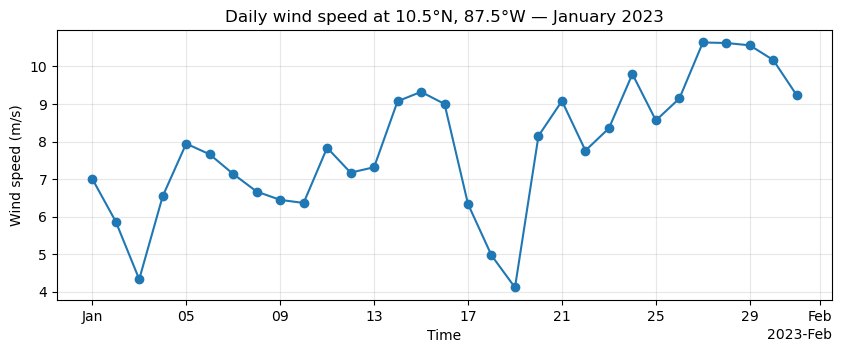

In [83]:
PT_LAT, PT_LON = 10.5, -87.5
speed_pt = speed.sel(latitude=PT_LAT, longitude=PT_LON, method="nearest")

fig, ax = plt.subplots(figsize=(10, 3.5))
speed_pt.plot(ax=ax, marker="o")
ax.set_ylabel("Wind speed (m/s)")
ax.set_title(f"Daily wind speed at {PT_LAT}°N, {-PT_LON}°W — January 2023")
ax.grid(alpha=0.3)
plt.show()

**✅ Check**
- The file is ~22 MB, `time: 744` (31 days × 24 h); after `resample`, `time: 31`.
- The wind speed is `NaN` over land: this product only exists over the ocean.
- On the Caribbean side, strong north-east **trade winds** (7–9 m/s). They cross Central America through the low gap of Nicaragua / northern Costa Rica.
- On the Pacific side, they come out as a **jet of ~10 m/s** (maximum near 11°N, 86.5°W) that fans out towards the **west-south-west**. That is exactly where the cold tongue of Exercise 1a was: the wind mixes and upwells cold water. Everywhere else on the Pacific side the wind is weak (2–5 m/s).
- On the time series: a burst at ~9 m/s on 14–16 January (the cold SST map of 16 January!), a lull on 19 January, and > 10 m/s at the end of the month.

---
### 🚀 Advanced track — wind and SST on the same map

Overlay the **contours of the January mean OSTIA SST** (Exercise 1a) on the wind map. Tips:
- select January in `sst` with `.sel(time="2023-01")` then average in time;
- `sst_jan.plot.contour(ax=ax, transform=ccrs.PlateCarree(), levels=..., colors="k")`;
- add labels with `ax.clabel(cs, fmt="%d")`.

Does the cold tongue sit under the jet? And the southward flow in the south-east corner (Gulf of Panama): does it also have a cold signature?

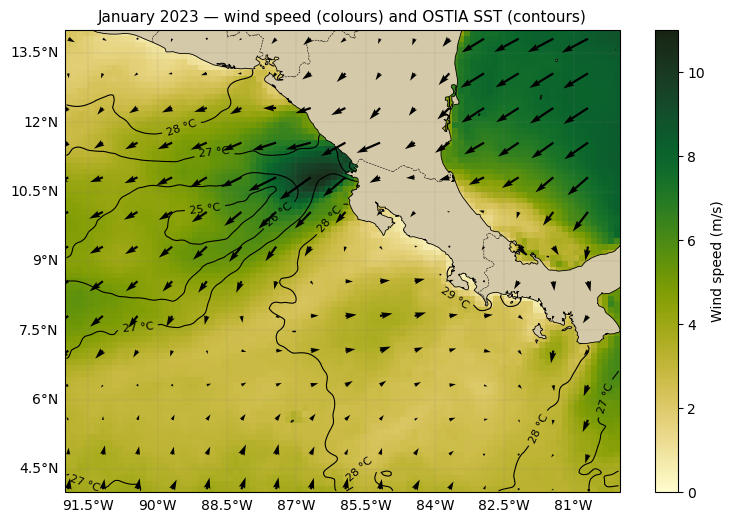

In [84]:
### STUDENT: # 🚀 Your code here
### BEGIN SOLUTION
sst_jan = sst.sel(time="2023-01").mean(dim="time")

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
speed_mean.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.speed,
                vmin=0, vmax=11, cbar_kwargs={"label": "Wind speed (m/s)"})
ax.quiver(u_mean.longitude[::step], u_mean.latitude[::step],
          u_mean[::step, ::step], v_mean[::step, ::step],
          transform=ccrs.PlateCarree(), scale=150, zorder=4)
cs = sst_jan.plot.contour(ax=ax, transform=ccrs.PlateCarree(),
                          levels=np.arange(23, 30, 1), colors="k", linewidths=0.8)
ax.clabel(cs, fmt="%d °C", fontsize=8)
base_map(ax, "January 2023 — wind speed (colours) and OSTIA SST (contours)")
plt.show()
### END SOLUTION
### HINT: January mean of the OSTIA SST: `sst.sel(time="2023-01").mean(dim="time")`.
### HINT: Redraw the wind map, then add `sst_jan.plot.contour(ax=ax, transform=ccrs.PlateCarree(), colors="k", ...)` and `ax.clabel(cs)`.

**✅ Check (advanced)**: the 25–26 °C contours sit right under the Papagayo jet and extend south-west of it, while the 28 °C contour stays away from it. In the south-east corner, the southward flow of the Gulf of Panama also has slightly cooler water (27 °C contour) under it.

---
## Recap

| Dataset | Type | Resolution | Frequency | Your file |
|---|---|---|---|---|
| OSTIA SST L4 | observation (satellite, interpolated) | 0.05° | daily | `data_tp2/sst_ostia_costarica_2023JFM.nc` |
| ARMOR3D | observation (satellite + in situ, 3D) | 0.125°, 30 levels | monthly | `data_tp2/armor3d_costarica_2023.nc` |
| GLORYS12 | reanalysis (ocean model + data assimilation) | 1/12°, 50 levels (31 kept) | monthly | `data_tp2/glorys12_costarica_2023JFM.nc` |
| Wind L4 | reanalysis (ERA5) corrected by satellite obs | 0.125° | hourly | `data_tp2/wind_l4_costarica_2023-01.nc` |

**Keep your `data_tp2/` folder**: you will reuse these files for the mini-project on Thursday.